# 01 Advanced EDA: IEEE-CIS Fraud Detection

This notebook is designed to feel closer to a project deliverable than a quick scratchpad. It focuses on:

- the shape and sparsity structure of the raw competition tables
- where fraud concentrates across time, amount, and categorical segments
- how missingness itself behaves like a predictive feature
- where train-to-test drift can create modeling risk

The goal is not just to look at plots, but to surface modeling decisions we should carry into the baseline and tree-based experiments.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.eda import (
    PLOT_COLORS,
    add_transaction_time_features,
    category_risk_table,
    classify_drift_level,
    compute_family_missingness,
    compute_psi_table,
    merge_identity_features,
    metric_cards_html,
    missingness_signal_table,
    quantile_fraud_table,
    reduce_memory_usage,
    set_plot_theme,
    standardize_identity_columns,
)

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 120)
sns.set_context("talk")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MAX_ROWS = None  # set to a smaller value like 200_000 for faster iteration
IDENTITY_FEATURES = ["DeviceType", "DeviceInfo", "id_30", "id_31", "id_33"]
DRIFT_COLUMNS = [
    "TransactionID",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "addr1",
    "dist1",
    "dist2",
    "C1",
    "D1",
    "D4",
    "D10",
    "D15",
    "M4",
    "M6",
]


In [2]:
train_transaction = reduce_memory_usage(
    pd.read_csv(DATA_DIR / "train_transaction.csv", nrows=MAX_ROWS)
)
train_identity = standardize_identity_columns(
    reduce_memory_usage(pd.read_csv(DATA_DIR / "train_identity.csv", nrows=MAX_ROWS))
)

test_transaction = reduce_memory_usage(
    pd.read_csv(DATA_DIR / "test_transaction.csv", usecols=DRIFT_COLUMNS, nrows=MAX_ROWS)
)
test_identity = standardize_identity_columns(
    reduce_memory_usage(
        pd.read_csv(
            DATA_DIR / "test_identity.csv",
            usecols=["TransactionID", "DeviceType", "DeviceInfo", "id-30", "id-31", "id-33"],
            nrows=MAX_ROWS,
        )
    )
)

train_core_columns = [
    "TransactionID",
    "isFraud",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "C1",
    "D1",
    "D4",
    "D10",
    "D15",
    "M4",
    "M6",
]
test_core_columns = [
    column
    for column in train_core_columns
    if column != "isFraud" and column in test_transaction.columns
]

train_core = merge_identity_features(train_transaction[train_core_columns], train_identity, IDENTITY_FEATURES)
train_core = add_transaction_time_features(train_core)
train_core["has_identity"] = train_core["TransactionID"].isin(train_identity["TransactionID"])

test_core = merge_identity_features(test_transaction[test_core_columns], test_identity, IDENTITY_FEATURES)
test_core = add_transaction_time_features(test_core)
test_core["has_identity"] = test_core["TransactionID"].isin(test_identity["TransactionID"])

inventory = pd.DataFrame(
    [
        {
            "table": "train_transaction",
            "rows": len(train_transaction),
            "columns": train_transaction.shape[1],
            "memory_mb": train_transaction.memory_usage(deep=True).sum() / 1024**2,
            "note": "full table loaded",
        },
        {
            "table": "train_identity",
            "rows": len(train_identity),
            "columns": train_identity.shape[1],
            "memory_mb": train_identity.memory_usage(deep=True).sum() / 1024**2,
            "note": "full table loaded",
        },
        {
            "table": "test_transaction",
            "rows": len(test_transaction),
            "columns": len(pd.read_csv(DATA_DIR / "test_transaction.csv", nrows=0).columns),
            "memory_mb": test_transaction.memory_usage(deep=True).sum() / 1024**2,
            "note": "feature slice loaded for drift diagnostics",
        },
        {
            "table": "test_identity",
            "rows": len(test_identity),
            "columns": len(pd.read_csv(DATA_DIR / "test_identity.csv", nrows=0).columns),
            "memory_mb": test_identity.memory_usage(deep=True).sum() / 1024**2,
            "note": "feature slice loaded for drift diagnostics",
        },
    ]
)

base_fraud_rate = float(train_core["isFraud"].mean())
identity_coverage = float(train_core["has_identity"].mean())
fraud_rate_with_identity = float(train_core.loc[train_core["has_identity"], "isFraud"].mean())
fraud_rate_without_identity = float(train_core.loc[~train_core["has_identity"], "isFraud"].mean())

print(f"Train transaction table: {train_transaction.shape}")
print(f"Train identity table: {train_identity.shape}")
print(f"Test drift slice: {test_transaction.shape}")
print(f"Fraud base rate: {base_fraud_rate:.2%}")


Train transaction table: (590540, 394)
Train identity table: (144233, 41)
Test drift slice: (506691, 18)
Fraud base rate: 3.50%


## Executive Snapshot

The first pass already tells us this is a sparse, highly imbalanced, and behaviorally segmented dataset. That combination usually rewards models that can:

- respect severe class imbalance
- handle sparse missing-value structure without flattening it away
- capture nonlinear interactions across product, device, and browser signals
- stay robust to distribution shift between the train and test periods


In [3]:
cards = [
    {
        "title": "Fraud Rate",
        "value": f"{base_fraud_rate:.2%}",
        "subtitle": "accuracy will be a misleading metric",
    },
    {
        "title": "Identity Coverage",
        "value": f"{identity_coverage:.1%}",
        "subtitle": "only a minority of transactions have identity rows",
    },
    {
        "title": "Fraud With Identity",
        "value": f"{fraud_rate_with_identity:.2%}",
        "subtitle": "identity-linked traffic is much riskier",
    },
    {
        "title": "Fraud Without Identity",
        "value": f"{fraud_rate_without_identity:.2%}",
        "subtitle": "baseline risk for the remaining transactions",
    },
]

display(HTML(metric_cards_html(cards)))

summary_points = [
    f"Only {base_fraud_rate:.2%} of train transactions are labeled as fraud, so precision-recall diagnostics matter more than raw accuracy.",
    f"Identity records cover {identity_coverage:.1%} of train transactions, but that slice has a {fraud_rate_with_identity:.2%} fraud rate versus {fraud_rate_without_identity:.2%} without identity.",
    "The test tables are only partially loaded here on purpose: we keep enough columns for drift analysis without unnecessarily bloating memory.",
]

summary_html = ''.join(f"<li style='margin-bottom:8px'>{point}</li>" for point in summary_points)
display(
    HTML(
        f'''
        <div style="background:#FFF8E8; border:1px solid #E8DAC3; border-radius:18px; padding:18px 22px; margin:8px 0 18px 0;">
            <div style="font-weight:700; font-size:18px; margin-bottom:10px; color:{PLOT_COLORS["ink"]};">
                What stands out immediately
            </div>
            <ul style="padding-left:18px; margin:0;">{summary_html}</ul>
        </div>
        '''
    )
)

display(
    inventory.style
    .format({"rows": "{:,}", "columns": "{:,}", "memory_mb": "{:,.1f}"})
    .hide(axis="index")
)


table,rows,columns,memory_mb,note
train_transaction,"590,540",394,"1,203.2",full table loaded
train_identity,"144,233",41,129.9,full table loaded
test_transaction,"506,691",393,185.4,feature slice loaded for drift diagnostics
test_identity,"141,907",41,36.1,feature slice loaded for drift diagnostics


## 1. Fraud Is Rare, But It Is Not Stationary

A strong EDA should show more than class imbalance. We also want to see whether fraud pressure changes over transaction time, and whether the amount distribution differs between fraud and legitimate traffic.


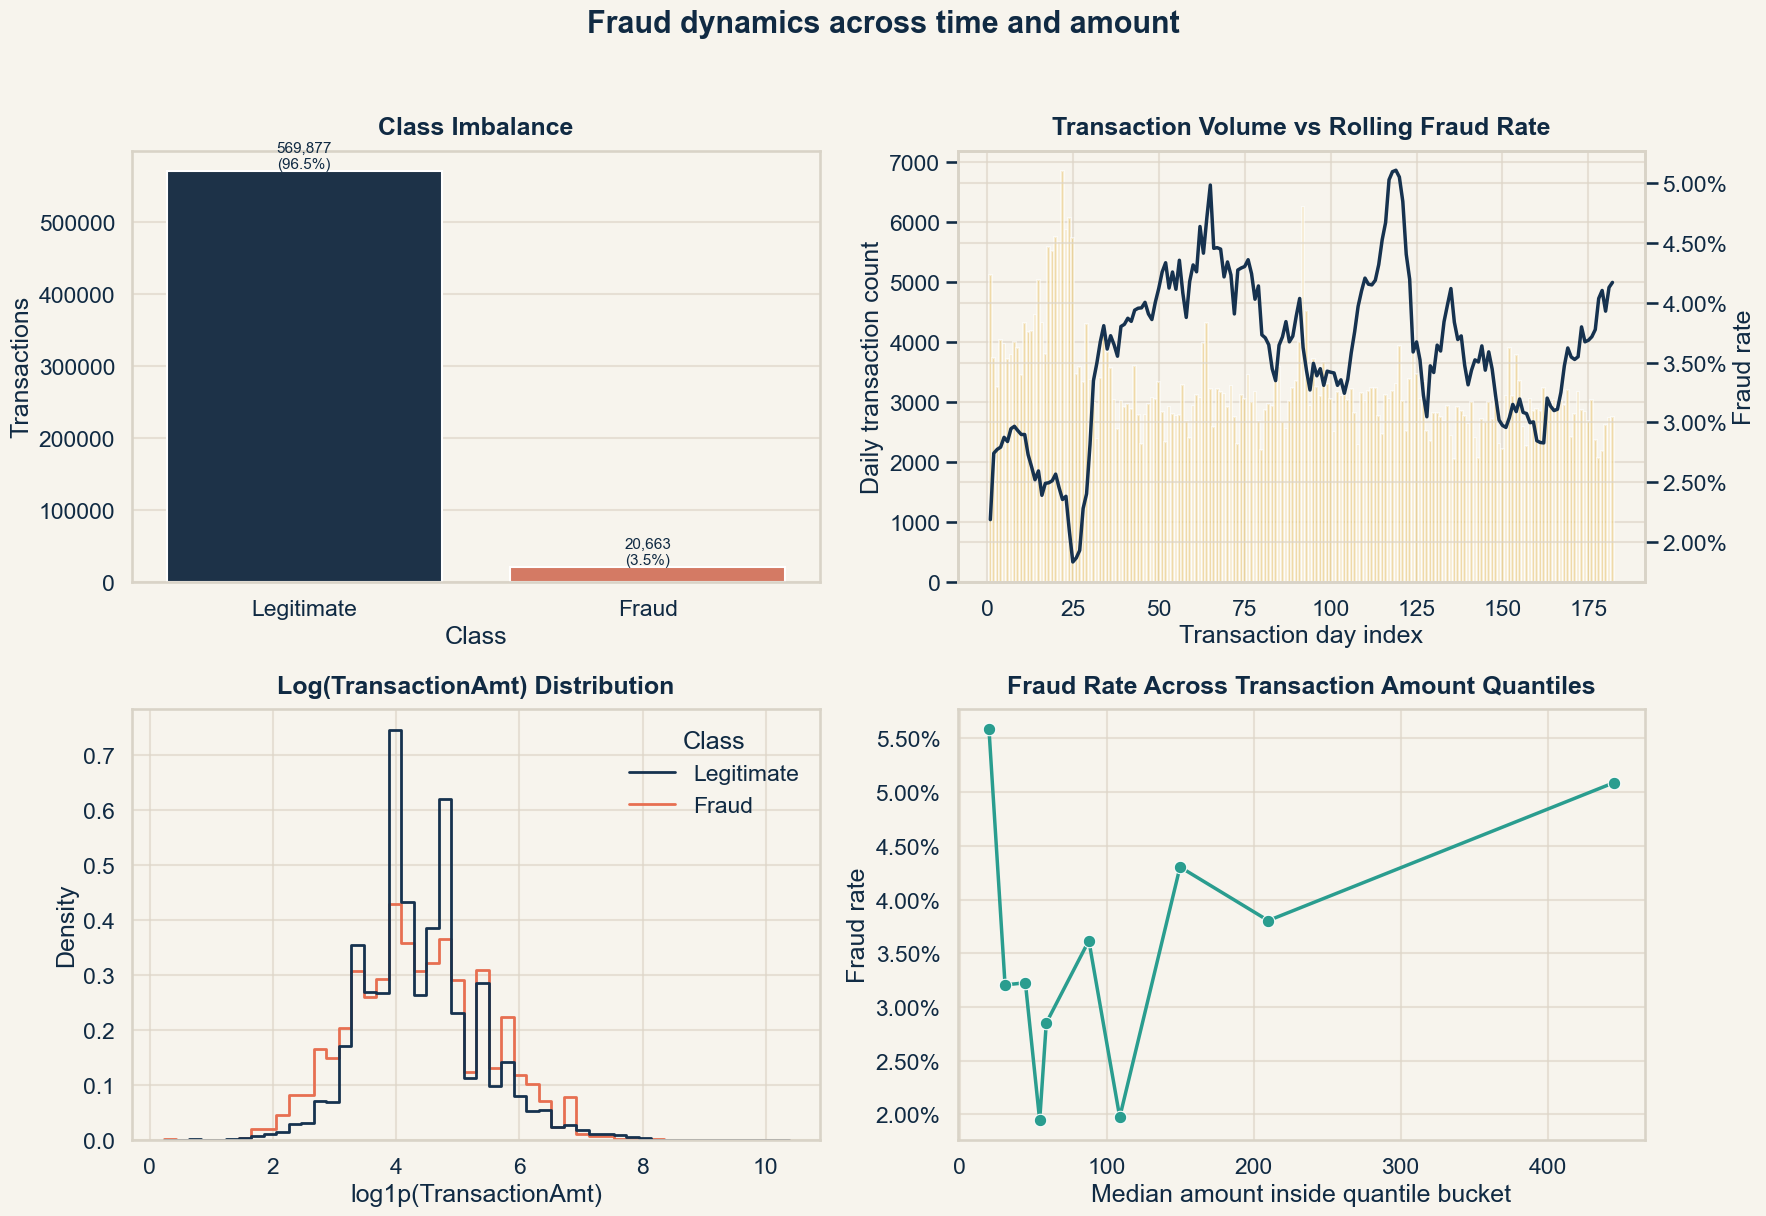

In [4]:
daily_profile = (
    train_core.groupby("TransactionDay", observed=False)
    .agg(transaction_count=("TransactionID", "size"), fraud_rate=("isFraud", "mean"))
    .reset_index()
)
daily_profile["fraud_rate_7d"] = daily_profile["fraud_rate"].rolling(7, min_periods=1).mean()

amount_profile = quantile_fraud_table(
    train_core,
    column="TransactionAmt",
    clip_upper_quantile=0.99,
)

amount_plot = train_core[["TransactionAmt", "isFraud"]].copy()
amount_plot["Class"] = amount_plot["isFraud"].map({0: "Legitimate", 1: "Fraud"})
amount_plot["LogTransactionAmt"] = np.log1p(amount_plot["TransactionAmt"])
amount_plot = amount_plot.sample(min(len(amount_plot), 200_000), random_state=42)

class_counts = (
    train_core["isFraud"]
    .map({0: "Legitimate", 1: "Fraud"})
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="count")
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=class_counts,
    x="Class",
    y="count",
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]],
    ax=axes[0, 0],
)
axes[0, 0].set_title("Class Imbalance")
axes[0, 0].set_ylabel("Transactions")
for patch, (_, row) in zip(axes[0, 0].patches, class_counts.iterrows()):
    rate = row["count"] / class_counts["count"].sum()
    axes[0, 0].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"{int(row['count']):,}\n({rate:.1%})",
        ha="center",
        va="bottom",
        fontsize=11,
    )

volume_ax = axes[0, 1]
risk_ax = volume_ax.twinx()
volume_ax.bar(
    daily_profile["TransactionDay"],
    daily_profile["transaction_count"],
    color=PLOT_COLORS["gold"],
    alpha=0.55,
    label="Daily volume",
)
risk_ax.plot(
    daily_profile["TransactionDay"],
    daily_profile["fraud_rate_7d"],
    color=PLOT_COLORS["navy"],
    linewidth=2.5,
    label="7-day fraud rate",
)
volume_ax.set_title("Transaction Volume vs Rolling Fraud Rate")
volume_ax.set_xlabel("Transaction day index")
volume_ax.set_ylabel("Daily transaction count")
risk_ax.set_ylabel("Fraud rate")
risk_ax.yaxis.set_major_formatter(PercentFormatter(1))

sns.histplot(
    data=amount_plot,
    x="LogTransactionAmt",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Log(TransactionAmt) Distribution")
axes[1, 0].set_xlabel("log1p(TransactionAmt)")
axes[1, 0].set_ylabel("Density")

sns.lineplot(
    data=amount_profile,
    x="median_value",
    y="fraud_rate",
    marker="o",
    linewidth=2.5,
    color=PLOT_COLORS["teal"],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Fraud Rate Across Transaction Amount Quantiles")
axes[1, 1].set_xlabel("Median amount inside quantile bucket")
axes[1, 1].set_ylabel("Fraud rate")
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1))

plt.suptitle("Fraud dynamics across time and amount", fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 2. Missingness Is Structure, Not Just Cleanup

In IEEE-CIS, missingness is not random housekeeping noise. Some columns are missing almost everywhere, while others become meaningfully more or less risky when they are absent.


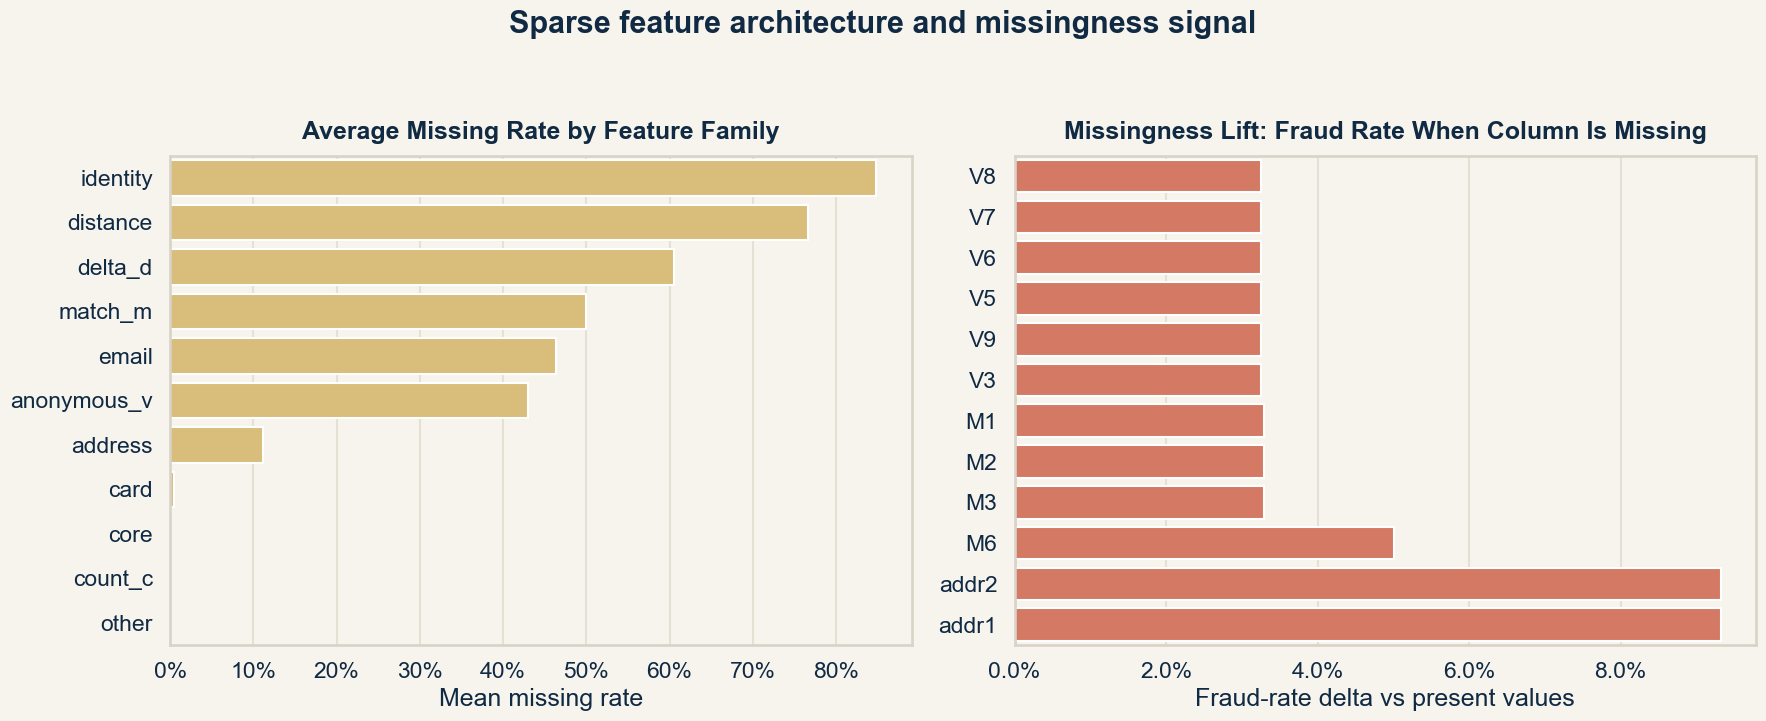

column,missing_rate,family,source
id_24,99.2%,identity,identity
id_25,99.1%,identity,identity
id_08,99.1%,identity,identity
id_07,99.1%,identity,identity
id_21,99.1%,identity,identity
id_26,99.1%,identity,identity
id_27,99.1%,identity,identity
id_23,99.1%,identity,identity
id_22,99.1%,identity,identity
dist2,93.6%,distance,transaction


column,family,missing_count,present_count,fraud_rate_missing,fraud_rate_present,lift_vs_present
addr2,address,"65,706","524,834",11.78%,2.46%,+9.32%
addr1,address,"65,706","524,834",11.78%,2.46%,+9.32%
M6,match_m,"169,360","421,180",7.07%,2.06%,+5.00%
M1,match_m,"271,100","319,440",5.28%,1.99%,+3.30%
M2,match_m,"271,100","319,440",5.28%,1.99%,+3.30%
M3,match_m,"271,100","319,440",5.28%,1.99%,+3.30%
V8,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%
V7,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%
V6,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%
V5,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%


In [5]:
missingness_profile = compute_family_missingness(train_transaction, train_identity)
family_missingness = (
    missingness_profile.groupby("family", observed=False)
    .agg(mean_missing_rate=("missing_rate", "mean"), feature_count=("column", "size"))
    .reset_index()
    .sort_values("mean_missing_rate", ascending=False)
)
missing_signal = missingness_signal_table(train_transaction, min_support=5_000)
top_missing_columns = missingness_profile.head(15).copy()
top_missing_lift = missing_signal.head(12).sort_values("lift_vs_present")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=family_missingness,
    x="mean_missing_rate",
    y="family",
    color=PLOT_COLORS["gold"],
    ax=axes[0],
)
axes[0].set_title("Average Missing Rate by Feature Family")
axes[0].set_xlabel("Mean missing rate")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))

sns.barplot(
    data=top_missing_lift,
    x="lift_vs_present",
    y="column",
    color=PLOT_COLORS["coral"],
    ax=axes[1],
)
axes[1].axvline(0, linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[1].set_title("Missingness Lift: Fraud Rate When Column Is Missing")
axes[1].set_xlabel("Fraud-rate delta vs present values")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))

plt.suptitle("Sparse feature architecture and missingness signal", fontsize=22, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

display(
    top_missing_columns.style
    .format({"missing_rate": "{:.1%}"})
    .hide(axis="index")
)

display(
    missing_signal.head(12).style
    .format(
        {
            "missing_count": "{:,}",
            "present_count": "{:,}",
            "fraud_rate_missing": "{:.2%}",
            "fraud_rate_present": "{:.2%}",
            "lift_vs_present": "{:+.2%}",
        }
    )
    .hide(axis="index")
)


## 3. Risk Is Concentrated In Specific Product, Device, And Browser Segments

The next question is whether certain customer or device segments carry visibly different fraud intensity. This is where the dataset starts to reveal why linear baselines can struggle without strong feature engineering.


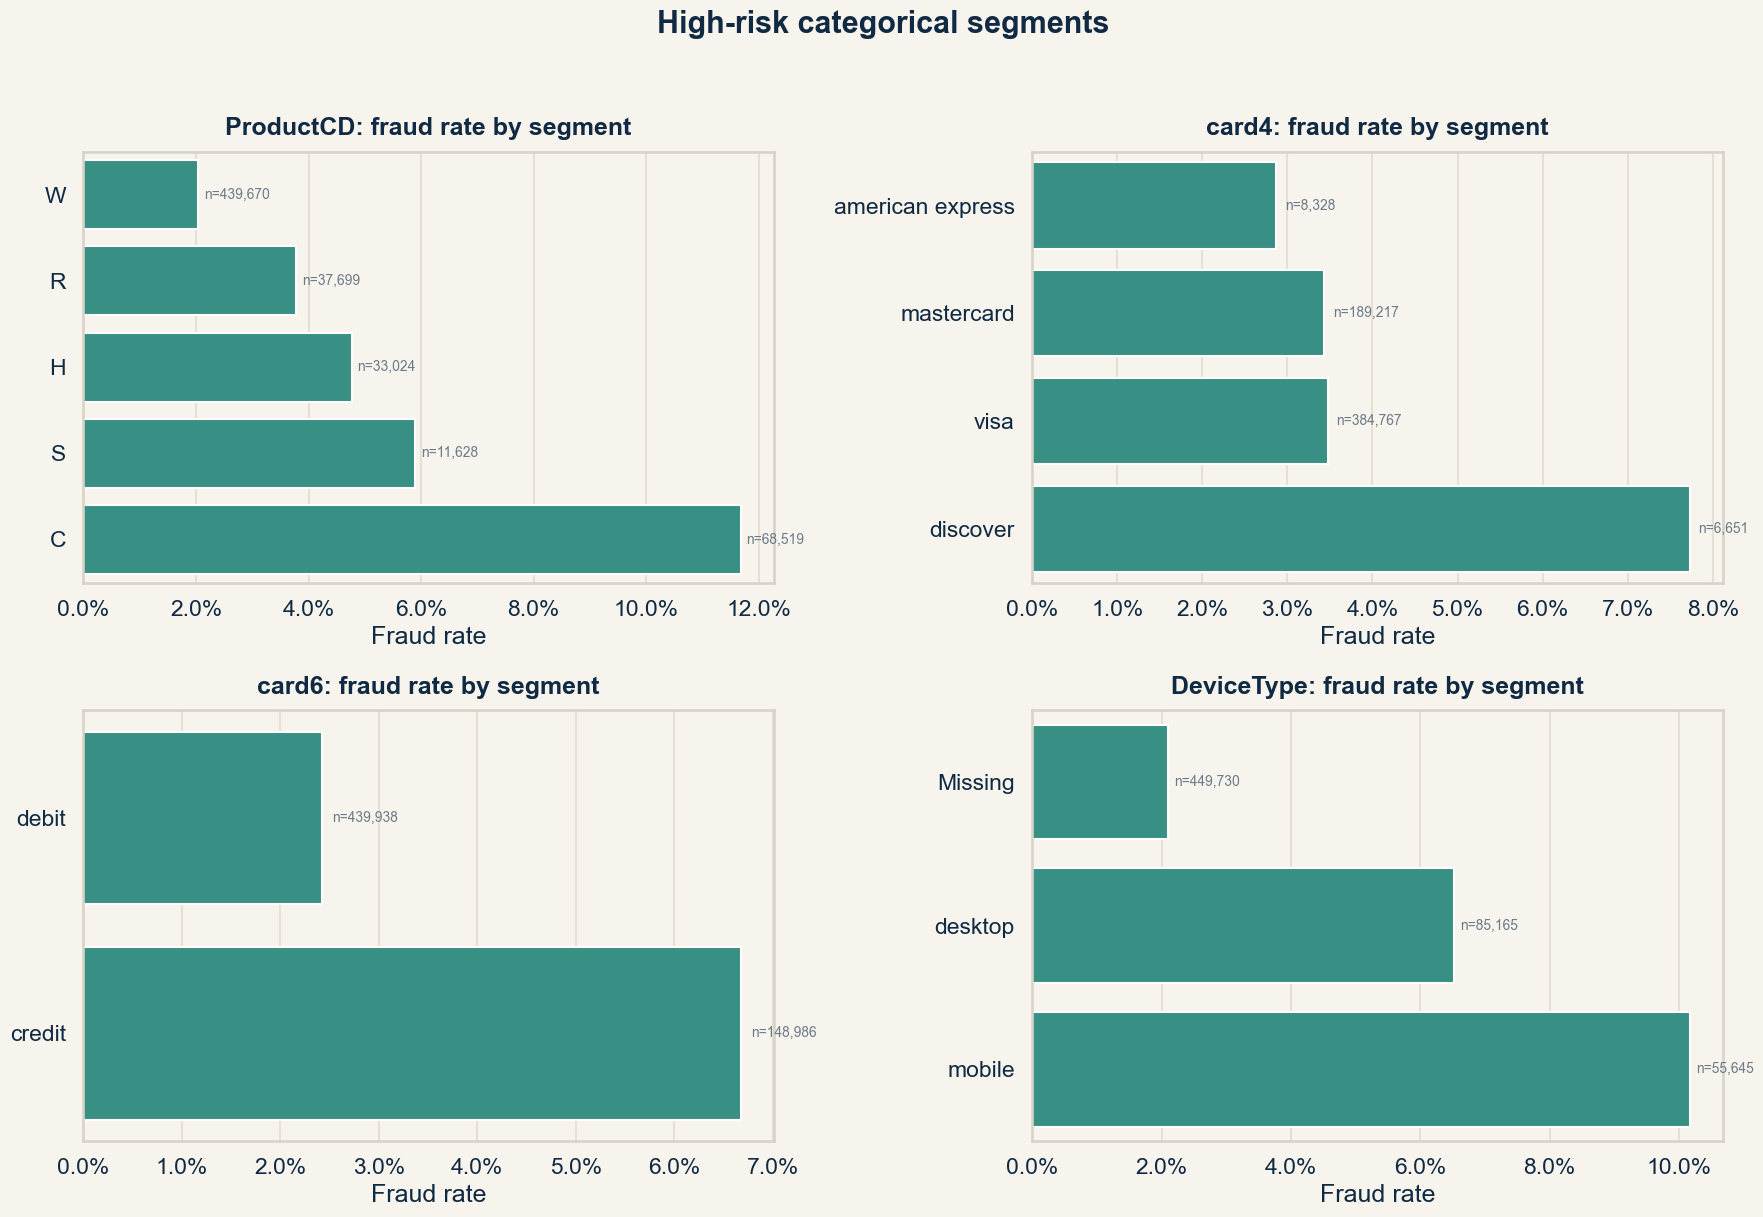

P_emaildomain,fraud_rate,count,share,lift_vs_base
outlook.com,9.46%,"5,096",0.86%,+5.96%
hotmail.com,5.30%,"45,250",7.66%,+1.80%
gmail.com,4.35%,"228,355",38.67%,+0.86%
icloud.com,3.14%,"6,267",1.06%,-0.36%
comcast.net,3.12%,"7,888",1.34%,-0.38%
Missing,2.95%,"94,456",15.99%,-0.55%
anonymous.com,2.32%,"36,998",6.27%,-1.18%
yahoo.com,2.28%,"100,934",17.09%,-1.22%
aol.com,2.18%,"28,289",4.79%,-1.32%


id_31,fraud_rate,count,share,lift_vs_base
chrome generic,16.81%,"4,778",0.81%,+13.31%
chrome 64.0 for android,15.89%,"3,473",0.59%,+12.40%
chrome 65.0 for android,14.72%,"3,336",0.56%,+11.22%
chrome 66.0 for android,12.98%,"2,349",0.40%,+9.49%
chrome 63.0 for android,11.25%,"5,806",0.98%,+7.75%
mobile safari generic,9.99%,"11,474",1.94%,+6.49%
chrome 65.0,9.88%,"6,871",1.16%,+6.38%
chrome 66.0,9.33%,"4,264",0.72%,+5.83%
chrome 64.0,9.16%,"6,711",1.14%,+5.67%
chrome 62.0 for android,7.68%,"2,097",0.36%,+4.18%


In [6]:
category_specs = [
    ("ProductCD", 5_000),
    ("card4", 5_000),
    ("card6", 5_000),
    ("DeviceType", 5_000),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, (column, min_count) in zip(axes.flatten(), category_specs):
    summary = category_risk_table(train_core, column, min_count=min_count, top_n=8).sort_values("fraud_rate")
    sns.barplot(
        data=summary,
        x="fraud_rate",
        y=column,
        color=PLOT_COLORS["teal"],
        ax=ax,
    )
    ax.set_title(f"{column}: fraud rate by segment")
    ax.set_xlabel("Fraud rate")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    for index, (_, row) in enumerate(summary.iterrows()):
        ax.text(
            row["fraud_rate"] + 0.001,
            index,
            f"n={int(row['count']):,}",
            va="center",
            fontsize=10,
            color=PLOT_COLORS["muted"],
        )

plt.suptitle("High-risk categorical segments", fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

email_risk = category_risk_table(train_core, "P_emaildomain", min_count=5_000, top_n=10)
browser_risk = category_risk_table(train_core, "id_31", min_count=2_000, top_n=12)

display(
    email_risk.style
    .format({"fraud_rate": "{:.2%}", "share": "{:.2%}", "count": "{:,}", "lift_vs_base": "{:+.2%}"})
    .hide(axis="index")
)

display(
    browser_risk.style
    .format({"fraud_rate": "{:.2%}", "share": "{:.2%}", "count": "{:,}", "lift_vs_base": "{:+.2%}"})
    .hide(axis="index")
)


## 4. Train-To-Test Drift Is Material For Several Features

A polished EDA should not stop at train-set storytelling. We also need to understand whether deployment-period behavior looks different from the training period. Population Stability Index (PSI) gives us a quick way to rank that risk.


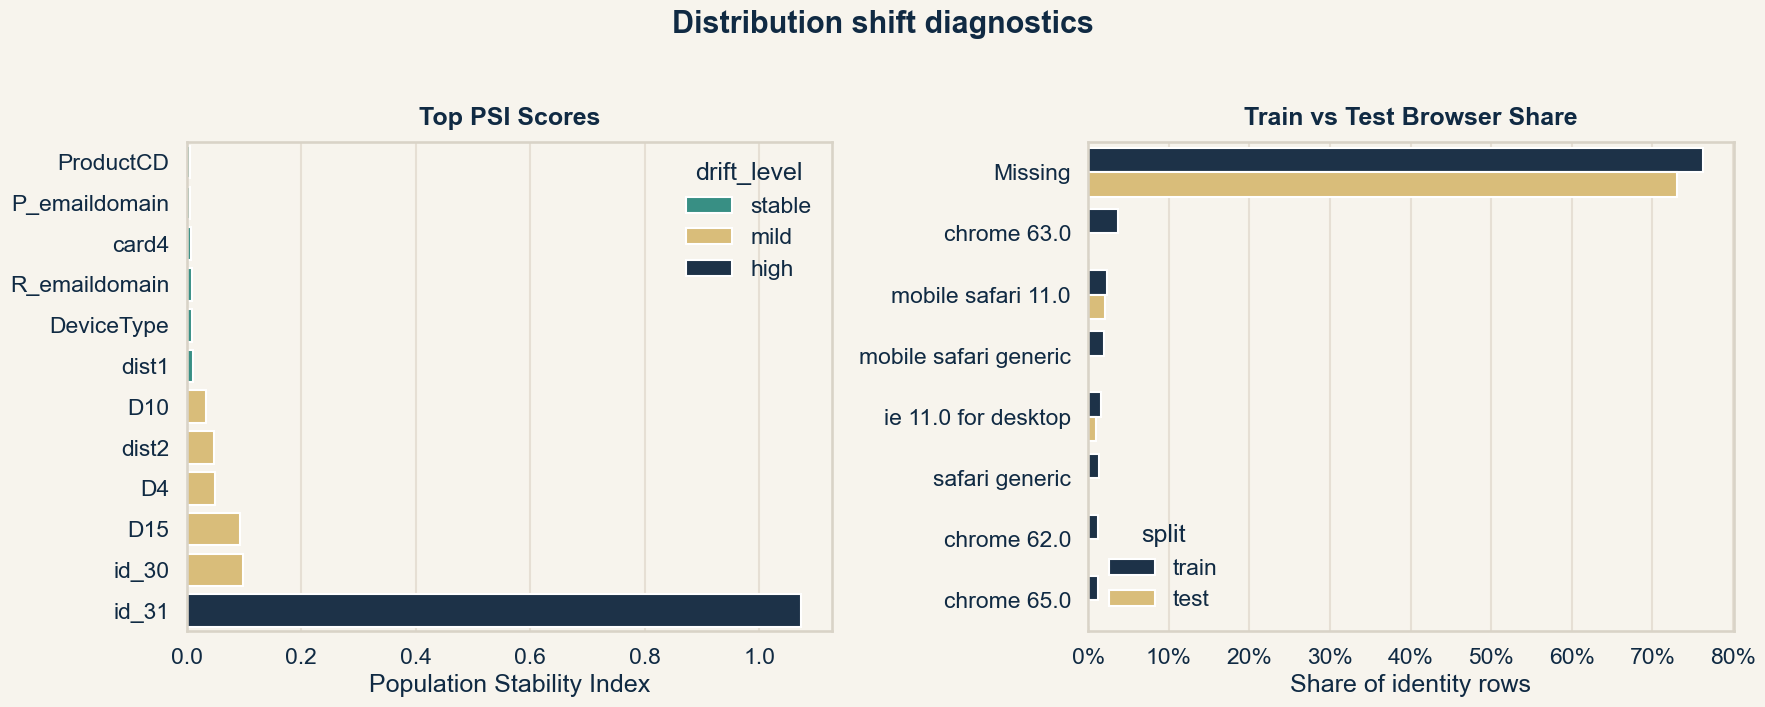

column,family,psi,drift_level
id_31,identity,1.074,high
id_30,identity,0.098,mild
D15,delta_d,0.093,mild
D4,delta_d,0.050,mild
dist2,distance,0.048,mild
D10,delta_d,0.033,mild
dist1,distance,0.011,stable
DeviceType,delta_d,0.009,stable
R_emaildomain,email,0.009,stable
card4,card,0.007,stable


In [7]:
categorical_drift_columns = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "M4",
    "M6",
    "DeviceType",
    "id_30",
    "id_31",
]
drift_columns = [
    "TransactionAmt",
    "addr1",
    "dist1",
    "dist2",
    "C1",
    "D1",
    "D4",
    "D10",
    "D15",
    *categorical_drift_columns,
]

psi_table = compute_psi_table(
    train_core,
    test_core,
    columns=drift_columns,
    categorical_columns=categorical_drift_columns,
)

top_drift = psi_table.head(12).sort_values("psi")

browser_train = train_core["id_31"].fillna("Missing").value_counts(normalize=True)
browser_test = test_core["id_31"].fillna("Missing").value_counts(normalize=True)
top_browsers = browser_train.head(8).index
browser_compare = pd.concat(
    [
        pd.DataFrame(
            {
                "id_31": top_browsers,
                "share": browser_train.reindex(top_browsers, fill_value=0).values,
                "split": "train",
            }
        ),
        pd.DataFrame(
            {
                "id_31": top_browsers,
                "share": browser_test.reindex(top_browsers, fill_value=0).values,
                "split": "test",
            }
        ),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette = {"stable": PLOT_COLORS["teal"], "mild": PLOT_COLORS["gold"], "moderate": PLOT_COLORS["coral"], "high": PLOT_COLORS["navy"]}
sns.barplot(
    data=top_drift,
    x="psi",
    y="column",
    hue="drift_level",
    dodge=False,
    palette=palette,
    ax=axes[0],
)
axes[0].set_title("Top PSI Scores")
axes[0].set_xlabel("Population Stability Index")
axes[0].set_ylabel("")

sns.barplot(
    data=browser_compare,
    x="share",
    y="id_31",
    hue="split",
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["gold"]],
    ax=axes[1],
)
axes[1].set_title("Train vs Test Browser Share")
axes[1].set_xlabel("Share of identity rows")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))

plt.suptitle("Distribution shift diagnostics", fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

display(
    psi_table.style
    .format({"psi": "{:.3f}"})
    .hide(axis="index")
)


## 5. Modeling Implications

The point of the EDA is to sharpen the next modeling decisions. The patterns above suggest a few concrete takeaways:

- **Imbalance is severe**: evaluation should emphasize PR-AUC, recall, and threshold-sensitive analysis instead of accuracy.
- **Missingness is informative**: dropping sparse columns blindly would remove signal, especially in several `D`, `V`, `M`, and address-related features.
- **Identity-linked traffic is high-risk**: the identity table is sparse, but when it exists it carries strong device and browser signal.
- **Categorical interactions matter**: product type, email domain, browser family, and card attributes show strong segmentation in fraud rate.
- **Drift is real**: features such as `id_31`, `id_30`, `D15`, and `D4` deserve monitoring and make time-aware validation a safer choice.

This gives us a clean bridge into the next notebooks: a strong baseline, then nonlinear models that can exploit sparse interactions more effectively.
